# 1. Literature-reported and raster-derived values

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

BASE = Path(os.getcwd())
OBS_FILE = BASE / 'meta_data_raw.xlsx'
RASTER_FILE = BASE / 'raster_derived_data.xlsx'
KEYS = ['Latitude', 'Longitude']
VARIABLES = ['MAT', 'MAP', 'SOC_i', 'pH']
UNITS = {'MAT': '°C', 'MAP': 'mm', 'SOC_i': 'g/kg', 'pH': ''}

observed = pd.read_excel(OBS_FILE)
raster = pd.read_excel(RASTER_FILE)
value_columns = [f'{v}_raster' for v in VARIABLES]
assert not set(value_columns).intersection(observed.columns)

def numeric(series, label):
    result = pd.to_numeric(series, errors='coerce')
    bad = series.notna() & result.isna()
    if bad.any():
        raise ValueError(f'{label}: nonnumeric values: {series[bad].head().tolist()}')
    return result.replace([np.inf, -np.inf], np.nan)

lookup = raster[KEYS + value_columns].copy()
for column in lookup:
    lookup[column] = numeric(lookup[column], column)
lookup = lookup.dropna(subset=KEYS)
if lookup.groupby(KEYS)[value_columns].nunique(dropna=False).gt(1).any().any():
    raise ValueError('Conflicting raster values at duplicate coordinates.')
lookup = lookup.drop_duplicates(KEYS)
matched = observed[KEYS].copy()
for key in KEYS:
    matched[key] = numeric(matched[key], key)
matched['_record'] = np.arange(len(observed))
matched = matched.merge(lookup, on=KEYS, how='left', sort=False,
                        validate='many_to_one', indicator=True)
matched = matched.sort_values('_record').reset_index(drop=True)
assert len(matched) == len(observed)
merged = observed.copy()
for column in value_columns:
    merged[column] = matched[column].to_numpy()
pd.testing.assert_frame_equal(merged[observed.columns], observed)
print(f"Matched {matched['_merge'].eq('both').sum()}/{len(observed)} records.")


Matched 708/708 records.


,Variable,Unit,N_records,N_unique_coordinates,Pearson_r,RMSE,MAE,bias_raster_minus_observed,N_excluded
0,MAT,°C,646,114,0.9806,0.9401,0.6461,0.2062,62
1,MAP,mm,643,113,0.9800,91.9303,70.7907,-17.5838,65
2,SOC_i,g/kg,646,118,0.3123,6.2775,4.8334,0.3879,62
3,pH,,567,100,0.7065,0.9879,0.6459,-0.3881,141


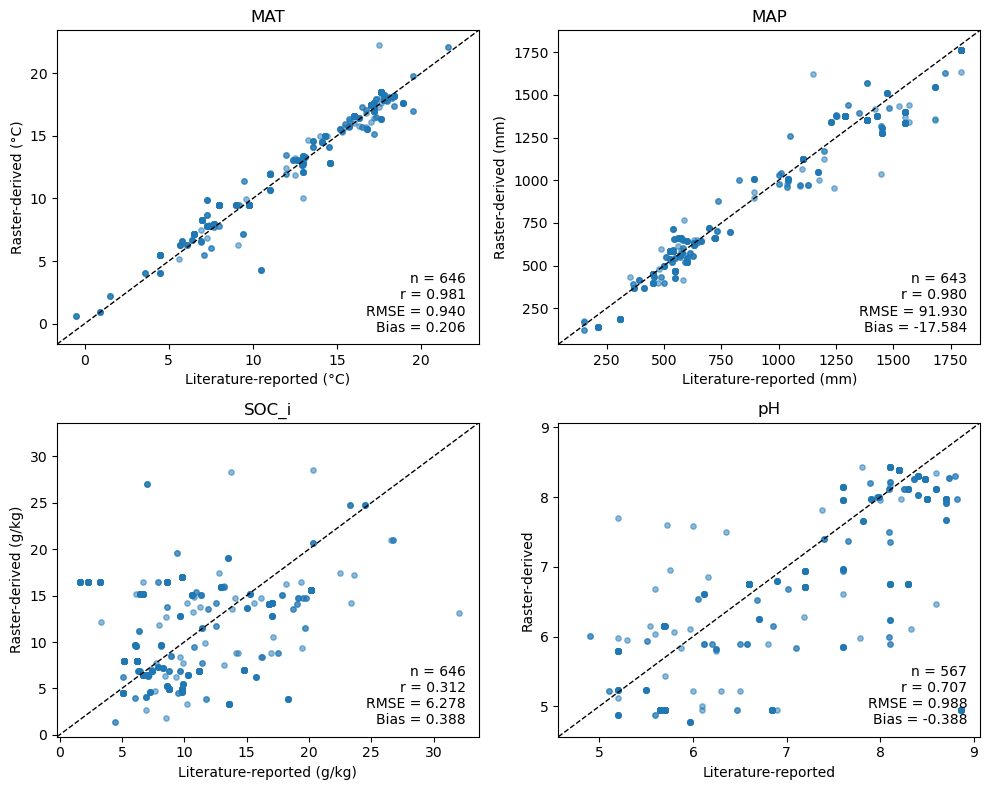

In [2]:
metric_rows, pairs = [], {}
for variable in VARIABLES:
    x = numeric(merged[variable], variable).to_numpy(dtype=float)
    y = merged[f'{variable}_raster'].to_numpy(dtype=float)
    keep = np.isfinite(x) & np.isfinite(y)
    x, y = x[keep], y[keep]
    pairs[variable] = (x, y)
    error = y - x
    pearson_r = (np.corrcoef(x, y)[0, 1]
                if len(x) >= 2 and np.std(x) > 0 and np.std(y) > 0 else np.nan)
    metric_rows.append({
        'Variable': variable, 'Unit': UNITS[variable], 'N_records': len(x),
        'N_unique_coordinates': matched.loc[keep, KEYS].drop_duplicates().shape[0],
        'Pearson_r': pearson_r,
        'RMSE': np.sqrt(np.mean(error**2)) if len(x) else np.nan,
        'MAE': np.mean(np.abs(error)) if len(x) else np.nan,
        'bias_raster_minus_observed': np.mean(error) if len(x) else np.nan,
        'N_excluded': len(observed) - len(x),
    })
metrics = pd.DataFrame(metric_rows)

metrics.to_csv(BASE / 'cropland_raster_strata' / 'validation_metrics.csv', index=False, encoding='utf-8-sig')
display(metrics.round(4))

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, variable in zip(axes.flat, VARIABLES):
    x, y = pairs[variable]
    row = metrics.loc[metrics.Variable.eq(variable)].iloc[0]
    ax.scatter(x, y, s=15, alpha=0.5)
    low = min(x.min(), y.min()) if len(x) else 0
    high = max(x.max(), y.max()) if len(x) else 1
    pad = max((high - low) * 0.05, 0.1)
    limits = (low - pad, high + pad)
    ax.plot(limits, limits, 'k--', linewidth=1)
    unit = f' ({UNITS[variable]})' if UNITS[variable] else ''
    ax.set(title=variable, xlabel=f'Literature-reported{unit}',
           ylabel=f'Raster-derived{unit}', xlim=limits, ylim=limits)
    ax.text(0.97, 0.03,
            f'n = {len(x)}\nr = {row.Pearson_r:.3f}\n'
            f'RMSE = {row.RMSE:.3f}\nBias = {row.bias_raster_minus_observed:.3f}',
            transform=ax.transAxes, ha='right', va='bottom')
fig.tight_layout()
plt.show()


# 2. Classification sensitivity

In [3]:
from pathlib import Path
from contextlib import ExitStack
import os, time, json, hashlib
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
from rasterio.windows import Window
from rasterio.transform import xy
from rasterio.warp import transform as transform_coords
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from scipy.optimize import linear_sum_assignment
from threadpoolctl import threadpool_limits
from IPython.display import display
import sklearn

SC_ROOT = Path(os.getcwd())
def sc_log(message):
    print(message, flush=True)

SC_RUNS = 100
SC_THREADS = 4
SC_SEEDS = np.arange(2000, 2000 + SC_RUNS, dtype=int)
sc_model_path = SC_ROOT / 'cropland_raster_strata/model_state.json'
manifest = json.loads(sc_model_path.read_text(encoding='utf-8'))
if sklearn.__version__ != manifest['sklearn_version']:
    raise ValueError(f"Use scikit-learn {manifest['sklearn_version']} to restore the fitted model.")
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def restore(estimator, state):
    for name, value in state.items():
        if isinstance(value, dict) and 'array' in value:
            value = np.asarray(value['array'], dtype=value['dtype'])
        setattr(estimator, name, value)
    return estimator

params = manifest['fitted_parameters']
sc_reference = restore(KMeans(), params['model'])
sc_scaler = restore(StandardScaler(), params['scaler'])
sc_pca = restore(PCA(), params['pca'])
sc_k = int(manifest['k'])
SC_WEIGHT = float(manifest['weight'])
assert sc_k == 3 and SC_WEIGHT == 1.0
SC_SAMPLE_SIZE = int(manifest['run_summary']['sample_size_target'])
SC_SAMPLE_SEED = int(manifest['run_summary']['random_state'])
sc_label_map = np.asarray(manifest['label_map'], dtype=int)
assert sorted(sc_label_map.tolist()) == list(range(1, sc_k + 1))
sc_features = manifest['features']
sc_bundle = {'crs': manifest['crs'], 'spatial_scale_m': manifest['spatial_scale_m']}
sc_raster_dir = SC_ROOT / manifest['raster_dir']
sc_paths = [sc_raster_dir / f'{v}_cropped.tif' for v in sc_features]
sc_crop_path = sc_raster_dir / 'cropland_cropped.tif'
with rasterio.open(sc_crop_path) as src:
    sc_shape, sc_transform, sc_crs = src.shape, src.transform, src.crs
    sc_ncrop = 0
    for row in range(0, sc_shape[0], 64):
        a = src.read(1, window=Window(0, row, sc_shape[1], min(64, sc_shape[0]-row)), masked=True)
        sc_ncrop += np.count_nonzero((~np.ma.getmaskarray(a)) & (a.data > 0))
for path in sc_paths:
    with rasterio.open(path) as src:
        assert src.shape == sc_shape and src.crs == sc_crs and src.transform.almost_equals(sc_transform)
sc_probability = min(1.0, SC_SAMPLE_SIZE / sc_ncrop)
sc_rng = np.random.default_rng(SC_SAMPLE_SEED)
sc_parts, sc_positions = [], []
with ExitStack() as stack:
    crop_src = stack.enter_context(rasterio.open(sc_crop_path))
    sources = [stack.enter_context(rasterio.open(p)) for p in sc_paths]
    for row in range(0, sc_shape[0], 64):
        height = min(64, sc_shape[0] - row)
        window = Window(0, row, sc_shape[1], height)
        crop = crop_src.read(1, window=window, masked=True)
        values = np.ma.column_stack([s.read(1, window=window, masked=True).ravel()
                                     for s in sources]).astype('float64').filled(np.nan)
        valid = ((~np.ma.getmaskarray(crop).ravel()) & (crop.data.ravel() > 0)
                 & np.isfinite(values).all(axis=1))
        # The row-major RNG stream exactly matches the original row-by-row sample.
        take = valid & (sc_rng.random(height * sc_shape[1]) < sc_probability)
        if take.any():
            sc_parts.append(values[take].astype('float64'))
            sc_positions.append(np.flatnonzero(take) + row * sc_shape[1])
sc_X = np.vstack(sc_parts)
sc_flat = np.concatenate(sc_positions)
if len(sc_X) > SC_SAMPLE_SIZE:
    keep = sc_rng.choice(len(sc_X), SC_SAMPLE_SIZE, replace=False)
    sc_X, sc_flat = sc_X[keep], sc_flat[keep]
sc_rows, sc_cols = np.divmod(sc_flat, sc_shape[1])
sc_gx, sc_gy = xy(sc_transform, sc_rows, sc_cols, offset='center')
sc_mx, sc_my = transform_coords(sc_crs, sc_bundle['crs'], sc_gx, sc_gy)
sc_lon, sc_lat = transform_coords(sc_crs, 'EPSG:4326', sc_gx, sc_gy)
assert len(sc_X) == manifest['run_summary']['sample_size'], 'Sample size differs from baseline.'
# The saved baseline used CEC values 100 times smaller than the current raster.
# Apply this legacy conversion only when BOTH sample moments match the baseline.
# Already-compatible rasters are left unchanged; other input changes still fail.
sc_feature_factors = np.ones(len(sc_features), dtype=float)
sc_cec = sc_features.index('CEC')
sc_cec_mean = sc_X[:, sc_cec].mean()
sc_cec_var = sc_X[:, sc_cec].var()
if not (np.isclose(sc_cec_mean, sc_scaler.mean_[sc_cec], rtol=1e-10, atol=1e-10)
        and np.isclose(sc_cec_var, sc_scaler.var_[sc_cec], rtol=1e-9, atol=1e-10)):
    if (np.isclose(sc_cec_mean / 100, sc_scaler.mean_[sc_cec], rtol=1e-10, atol=1e-10)
            and np.isclose(sc_cec_var / 10000, sc_scaler.var_[sc_cec], rtol=1e-9, atol=1e-10)):
        sc_X[:, sc_cec] /= 100
        sc_feature_factors[sc_cec] = 0.01
        sc_log('CEC divided by 100 in memory to match the saved baseline scale.')
    else:
        raise ValueError('CEC differs from the saved baseline beyond the known factor of 100. '
                         'Rebuild the baseline with matching rasters before sensitivity analysis.')
np.testing.assert_allclose(sc_X.mean(axis=0), sc_scaler.mean_, rtol=1e-10, atol=1e-10)
np.testing.assert_allclose(sc_X.var(axis=0), sc_scaler.var_, rtol=1e-9, atol=1e-10)
with threadpool_limits(limits=SC_THREADS):
    sc_pcs = sc_pca.transform(sc_scaler.transform(sc_X))
    sc_cluster = np.ascontiguousarray(np.column_stack([
        sc_pcs, np.sqrt(SC_WEIGHT) * np.column_stack([sc_mx, sc_my]) / sc_bundle['spatial_scale_m']]))
    sc_ref_raw = sc_reference.predict(sc_cluster)
np.testing.assert_allclose(np.sum((sc_cluster-sc_reference.cluster_centers_[sc_ref_raw])**2),
                           sc_reference.inertia_, rtol=1e-9)
sc_ref_region = sc_label_map[sc_ref_raw]
sc_log(f'Original sample verified: {len(sc_X):,} pixels; {sc_pca.n_components_} PCs; K={sc_k}; weight={SC_WEIGHT}; n_init={sc_reference.n_init}.')
sc_log(f'PCA explained variance: {sc_pca.explained_variance_ratio_.sum():.6f}; sklearn={sklearn.__version__}.')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
SC_FRACTION = 0.80
SC_PCA_TARGET = 0.90
sc_ntrain = int(np.floor(SC_FRACTION * len(sc_X)))
sc_spatial = np.sqrt(SC_WEIGHT) * np.column_stack([sc_mx, sc_my]) / sc_bundle['spatial_scale_m']
sc_sample_hash = hashlib.sha256(sc_X.tobytes() + sc_flat.tobytes()).hexdigest()
sc_log(f'Baseline uses all {len(sc_X):,} original sampled pixels; each sensitivity fit uses {sc_ntrain:,} pixels without replacement.')


Original sample verified: 149,445 pixels; 4 PCs; K=3; weight=1.0; n_init=20.
PCA explained variance: 0.904729; sklearn=1.8.0.
Baseline uses all 149,445 original sampled pixels; each sensitivity fit uses 119,556 pixels without replacement.


In [4]:
sc_votes = np.zeros((len(sc_X), sc_k), dtype=np.uint16)
sc_in_training = np.zeros((SC_RUNS, len(sc_X)), dtype=bool)
sc_oob_n = np.zeros(len(sc_X), dtype=np.uint16)
sc_oob_correct = np.zeros(len(sc_X), dtype=np.uint16)
sc_run_rows = []
sc_start = time.perf_counter()
with threadpool_limits(limits=SC_THREADS):
    for run, seed in enumerate(SC_SEEDS):
        sample_seed, cluster_seed = [int(s.generate_state(1)[0]) for s in np.random.SeedSequence(int(seed)).spawn(2)]
        train = np.random.default_rng(sample_seed).choice(len(sc_X), sc_ntrain, replace=False)
        sc_in_training[run, train] = True
        omitted = ~sc_in_training[run]
        run_scaler = StandardScaler()
        train_scaled = run_scaler.fit_transform(sc_X[train])
        full_pca = PCA(svd_solver='full').fit(train_scaled)
        n_pcs = int(np.searchsorted(np.cumsum(full_pca.explained_variance_ratio_), SC_PCA_TARGET)+1)
        run_pca = PCA(n_components=n_pcs, svd_solver='full')
        train_pcs = run_pca.fit_transform(train_scaled)
        train_cluster = np.column_stack([train_pcs, sc_spatial[train]])
        params = sc_reference.get_params(deep=False).copy()
        params['random_state'] = cluster_seed
        run_model = KMeans(**params).fit(train_cluster)
        evaluation_pcs = run_pca.transform(run_scaler.transform(sc_X))
        evaluation_cluster = np.column_stack([evaluation_pcs, sc_spatial])
        raw = run_model.predict(evaluation_cluster)
        overlap = np.bincount(sc_ref_raw*sc_k + raw, minlength=sc_k*sc_k).reshape(sc_k,sc_k)
        baseline_ids, fitted_ids = linear_sum_assignment(-overlap)
        mapping = np.empty(sc_k, dtype=int)
        mapping[fitted_ids] = baseline_ids
        aligned_raw = mapping[raw]
        aligned = sc_label_map[aligned_raw]
        correct = aligned == sc_ref_region
        sc_votes[np.arange(len(sc_X)), aligned-1] += 1
        sc_oob_n += omitted
        sc_oob_correct += omitted & correct
        sc_run_rows.append({
            'Run':run+1, 'Master_seed':int(seed), 'Sample_seed':sample_seed,
            'KMeans_seed':cluster_seed, 'N_train':len(train), 'N_evaluation':len(sc_X),
            'N_omitted':int(omitted.sum()), 'K':sc_k, 'Spatial_weight':SC_WEIGHT,
            'PCA_components':n_pcs, 'PCA_cumulative_variance':run_pca.explained_variance_ratio_.sum(),
            'ARI_vs_baseline':adjusted_rand_score(sc_ref_raw,raw),
            'Agreement_vs_baseline':correct.mean(),
            'OOB_agreement_vs_baseline':correct[omitted].mean(),
            'Train_agreement_vs_baseline':correct[~omitted].mean(),
            'N_init':run_model.n_init, 'Iterations':run_model.n_iter_,
            'Alignment_new_to_baseline_raw':json.dumps(mapping.tolist()),
        })
        if run == 0 or (run+1)%5 == 0:
            sc_log(f'Run {run+1}/{SC_RUNS}: PCs={n_pcs}; ARI={sc_run_rows[-1]["ARI_vs_baseline"]:.6f}; elapsed={time.perf_counter()-sc_start:.1f}s')
assert np.all(sc_votes.sum(axis=1)==SC_RUNS)
assert np.all(sc_in_training.sum(axis=1)==sc_ntrain)
sc_stability = sc_votes.max(axis=1)/SC_RUNS
sc_modal = sc_votes.argmax(axis=1)+1
sc_tie = (sc_votes==sc_votes.max(axis=1,keepdims=True)).sum(axis=1)>1
sc_baseline_agreement = sc_votes[np.arange(len(sc_X)),sc_ref_region-1]/SC_RUNS
sc_oob_agreement = np.divide(sc_oob_correct,sc_oob_n,out=np.full(len(sc_X),np.nan),where=sc_oob_n>0)
sc_pixels = pd.DataFrame({
    'Source_row':sc_rows,'Source_col':sc_cols,'Longitude':sc_lon,'Latitude':sc_lat,
    'Baseline_region':sc_ref_region,'Modal_region':sc_modal,'Modal_tie':sc_tie,
    'Stability':sc_stability,'Agreement_with_baseline':sc_baseline_agreement,
    'N_out_of_bag_runs':sc_oob_n,'OOB_agreement_with_baseline':sc_oob_agreement,
})
for cid in range(1,sc_k+1): sc_pixels[f'Votes_region_{cid}']=sc_votes[:,cid-1]
sc_summary_rows=[]
for cid in [0,1,2,3]:
    use=np.ones(len(sc_X),dtype=bool) if cid==0 else sc_ref_region==cid
    a=sc_stability[use]
    sc_summary_rows.append({
        'Region':'All' if cid==0 else f'Region {cid}', 'N_pixels':len(a),
        'Mean_stability':a.mean(),'Median_stability':np.median(a),
        'P05_stability':np.quantile(a,.05),'Minimum_stability':a.min(),
        'Fraction_gt_0_90':np.mean(a>.90),'Fraction_ge_0_90':np.mean(a>=.90),
        'Fraction_perfect':np.mean(a==1),
        'Mean_agreement_with_baseline':sc_baseline_agreement[use].mean(),
        'Fraction_modal_differs_from_baseline':np.mean(sc_modal[use]!=sc_ref_region[use]),
        'N_modal_ties':int(sc_tie[use].sum()),
        'Pooled_OOB_agreement_with_baseline':sc_oob_correct[use].sum()/sc_oob_n[use].sum(),
    })
sc_summary=pd.DataFrame(sc_summary_rows)
sc_run_metrics=pd.DataFrame(sc_run_rows)
sc_method={
    'Baseline':'Original saved pipeline fitted on 100% of the verified original sample',
    'Reference_notebook':'climate_soil_classification.ipynb; final weight=1',
    'Model_SHA256':hashlib.sha256(sc_model_path.read_bytes()).hexdigest(),
    'Evaluation_sample_SHA256':sc_sample_hash,
    'Raster_to_baseline_factors':dict(zip(sc_features, sc_feature_factors.tolist())),
    'N_baseline_and_evaluation':len(sc_X),'N_train_each_run':sc_ntrain,
    'Sampling_fraction':SC_FRACTION,'Sampling':'Without replacement within run; independent across runs',
    'Sample_seed_baseline':SC_SAMPLE_SEED,'Run_master_seeds':SC_SEEDS.tolist(),'N_runs':SC_RUNS,
    'Refit':'StandardScaler, PCA and KMeans independently in every run',
    'PCA_target':SC_PCA_TARGET,'PCA_rule':'Minimum PCs reaching target; full SVD',
    'K':sc_k,'Spatial_weight':SC_WEIGHT,'Spatial_scale_m':sc_bundle['spatial_scale_m'],
    'KMeans_n_init':sc_reference.n_init,'Sklearn_version':sklearn.__version__,
    'Alignment':'Hungarian maximum overlap on the common evaluation sample against baseline',
    'Stability':'Maximum aligned label count / N_runs',
    'Baseline_agreement':'Aligned votes for baseline region / 100',
    'OOB_agreement':'Baseline agreement only for runs that omitted the evaluated pixel from fitting',
    'Modal_ties':'Lowest region ID selected if tied; ties are explicitly flagged',
    'Scope':'Subsampling plus preprocessing refit plus initialization sensitivity; fixed K and weight',
    'Evaluation_note':'All original sampled pixels evaluated in every run; includes fit pixels; not independent predictive validation',
    'Weighting':'Equal sample-pixel weights; not national cropland-area fractions',
}
sc_summary_path = SC_ROOT / 'cropland_raster_strata' / 'classification_sensitivity_summary.xlsx'
with pd.ExcelWriter(sc_summary_path) as writer:
    sc_summary.to_excel(writer, sheet_name='Region_summary', index=False)
    sc_run_metrics.to_excel(writer, sheet_name='Run_metrics', index=False)
    pd.DataFrame({'Parameter': sc_method.keys(),
                  'Value': [str(v) for v in sc_method.values()]}).to_excel(
        writer, sheet_name='Methods', index=False)
display(sc_summary.round(6))
display(sc_run_metrics.round(6))
sc_log(f'Completed {SC_RUNS} refitted 80% subsampling runs; summary saved to {sc_summary_path}.')


Run 1/100: PCs=4; ARI=0.999559; elapsed=1.7s
Run 5/100: PCs=4; ARI=0.999493; elapsed=3.4s
Run 10/100: PCs=4; ARI=0.999486; elapsed=5.5s
Run 15/100: PCs=4; ARI=0.999025; elapsed=7.6s
Run 20/100: PCs=4; ARI=0.998592; elapsed=10.5s
Run 25/100: PCs=4; ARI=0.999513; elapsed=13.0s
Run 30/100: PCs=4; ARI=0.999526; elapsed=15.7s
Run 35/100: PCs=4; ARI=0.999266; elapsed=18.2s
Run 40/100: PCs=4; ARI=0.999930; elapsed=20.7s
Run 45/100: PCs=4; ARI=0.999266; elapsed=23.2s
Run 50/100: PCs=4; ARI=0.999338; elapsed=25.7s
Run 55/100: PCs=4; ARI=0.999790; elapsed=28.1s
Run 60/100: PCs=4; ARI=0.999741; elapsed=30.6s
Run 65/100: PCs=4; ARI=0.999518; elapsed=33.2s
Run 70/100: PCs=4; ARI=0.999674; elapsed=35.7s
Run 75/100: PCs=4; ARI=0.999733; elapsed=38.2s
Run 80/100: PCs=4; ARI=0.999251; elapsed=40.7s
Run 85/100: PCs=4; ARI=0.998958; elapsed=43.2s
Run 90/100: PCs=4; ARI=0.999385; elapsed=45.7s
Run 95/100: PCs=4; ARI=0.999070; elapsed=48.1s
Run 100/100: PCs=4; ARI=0.999345; elapsed=50.8s


,Region,N_pixels,Mean_stability,Median_stability,P05_stability,Minimum_stability,Fraction_gt_0_90,Fraction_ge_0_90,Fraction_perfect,Mean_agreement_with_baseline,Fraction_modal_differs_from_baseline,N_modal_ties,Pooled_OOB_agreement_with_baseline
0,All,149445,0.999773,1.0,1.0,0.50,0.999277,0.999304,0.998387,0.999765,0.000054,3,0.999753
1,Region 1,27044,0.999669,1.0,1.0,0.50,0.999039,0.999113,0.998114,0.999669,0.000000,2,0.999655
2,Region 2,53596,0.999726,1.0,1.0,0.50,0.999086,0.999123,0.997556,0.999726,0.000019,1,0.999716
3,Region 3,68805,0.999850,1.0,1.0,0.53,0.999520,0.999520,0.999143,0.999833,0.000102,0,0.999820


,Run,Master_seed,Sample_seed,KMeans_seed,N_train,N_evaluation,N_omitted,K,Spatial_weight,PCA_components,PCA_cumulative_variance,ARI_vs_baseline,Agreement_vs_baseline,OOB_agreement_vs_baseline,Train_agreement_vs_baseline,N_init,Iterations,Alignment_new_to_baseline_raw
0,1,2000,4082782755,1131335558,119556,149445,29889,3,1.0,4,0.904858,0.999559,0.999839,0.999766,0.999858,20,4,"[2, 0, 1]"
1,2,2001,1879181640,48966784,119556,149445,29889,3,1.0,4,0.904444,0.999726,0.999900,0.999900,0.999900,20,7,"[0, 2, 1]"
2,3,2002,4033461582,746300258,119556,149445,29889,3,1.0,4,0.904782,0.999484,0.999819,0.999900,0.999799,20,6,"[2, 0, 1]"
3,4,2003,3029203617,662510440,119556,149445,29889,3,1.0,4,0.904698,0.999052,0.999679,0.999565,0.999707,20,6,"[1, 2, 0]"
4,5,2004,1364947248,3574803785,119556,149445,29889,3,1.0,4,0.904815,0.999493,0.999813,0.999833,0.999808,20,6,"[2, 0, 1]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,2095,2234793170,3312329777,119556,149445,29889,3,1.0,4,0.904725,0.999470,0.999806,0.999732,0.999824,20,6,"[0, 1, 2]"
96,97,2096,609228728,1405810997,119556,149445,29889,3,1.0,4,0.904732,0.999148,0.999699,0.999699,0.999699,20,5,"[1, 0, 2]"
97,98,2097,821293204,2021672840,119556,149445,29889,3,1.0,4,0.904854,0.999679,0.999886,0.999766,0.999916,20,6,"[1, 0, 2]"
98,99,2098,1646640451,1156032150,119556,149445,29889,3,1.0,4,0.904660,0.998988,0.999665,0.999699,0.999657,20,6,"[0, 1, 2]"


Completed 100 refitted 80% subsampling runs; summary saved to c:\Meta\data_SD\meta_test\cropland_raster_strata\classification_sensitivity_summary.xlsx.


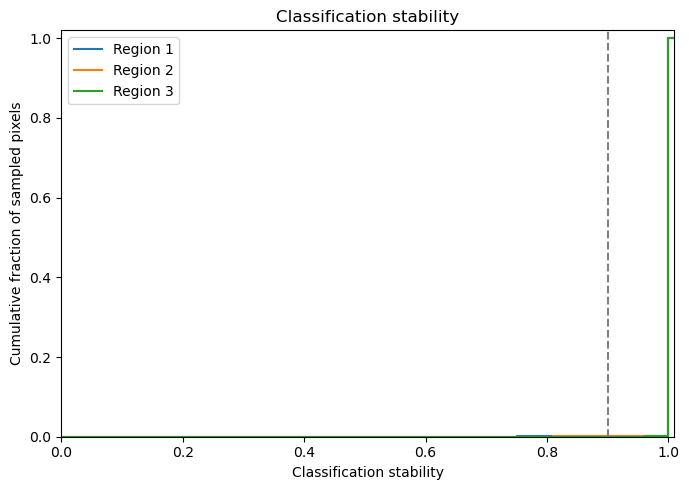

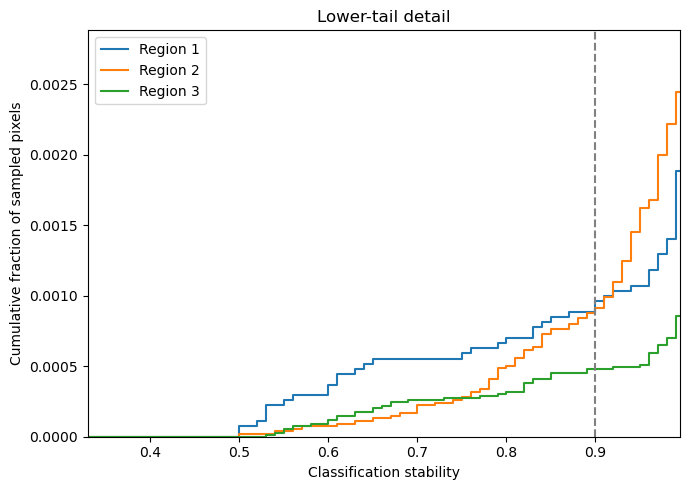

In [5]:
# Plot the in-memory results after running the sensitivity analysis.
pixels = sc_pixels
regions = sorted(pixels['Baseline_region'].unique())
tail_max = max((pixels.loc[pixels.Baseline_region.eq(r), 'Stability'] < 1).mean()
               for r in regions)
for detail in [False, True]:
    fig, ax = plt.subplots(figsize=(7, 5))
    for region in regions:
        values = pixels.loc[pixels.Baseline_region.eq(region), 'Stability'].to_numpy()
        unique, counts = np.unique(values, return_counts=True)
        ax.step(np.r_[0, unique, 1.01], np.r_[0, np.cumsum(counts) / len(values), 1],
                where='post', label=f'Region {region}')
    ax.axvline(0.90, color='gray', linestyle='--')
    ax.set(xlabel='Classification stability', ylabel='Cumulative fraction of sampled pixels',
           title='Lower-tail detail' if detail else 'Classification stability',
           xlim=(0.33, 0.995) if detail else (0, 1.01),
           ylim=(0, max(tail_max * 1.18, 1e-5)) if detail else (0, 1.02))
    ax.legend()
    fig.tight_layout()
    plt.show()
